# ScienceQA RAG Pipeline Evaluation & Visualization

This notebook evaluates the ScienceQA Retrieval-Augmented Generation (RAG) pipeline on the test set, reports accuracy by grade and subject, and visualizes the results.

In [80]:
# 1. Import Required Libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Optional: for interactive plots
import plotly.express as px

## 2. Load Model and Data
Load the CustomBERTEmbedding model and the ScienceQA training and test datasets.

In [81]:
import sys
import os

# Add the models directory to sys.path (robust for Jupyter)
models_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "models"))
if models_dir not in sys.path:
    sys.path.insert(0, models_dir)

from custom_bert import CustomBERTEmbedding

VOCAB_SIZE = 30522
EMBED_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 6
MAX_SEQ_LENGTH = 128

# Load model
model = CustomBERTEmbedding(VOCAB_SIZE, EMBED_DIM, NUM_HEADS, NUM_LAYERS, MAX_SEQ_LENGTH)
model.load_state_dict(torch.load(os.path.join(models_dir, "custom_bert.pth"), map_location=torch.device('cpu')))
model.eval()

# Load data
data_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
train_path = os.path.join(data_dir, "train.json")
test_path = os.path.join(data_dir, "test.json")
import json
with open(train_path, 'r', encoding='utf-8') as f:
    data_train = pd.DataFrame(list(json.load(f).values()))
with open(test_path, 'r', encoding='utf-8') as f:
    data_test = pd.DataFrame(list(json.load(f).values()))

print(f"Train samples: {len(data_train)} | Test samples: {len(data_test)}")

/Users/jessicalim/miniconda3/envs/ml_project/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/var/folders/7n/sdnmyc4j33q0y4lz8rx2m3wc0000gn/T/ipykernel_50391/1902252802.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowl

Train samples: 6517 | Test samples: 2195


## 3. Embed Training Lectures
Embed the training lectures using the model if embeddings do not already exist.

In [82]:
def simple_tokenizer(text, vocab_size=VOCAB_SIZE, max_seq_length=MAX_SEQ_LENGTH):
    tokens = text.lower().split()
    ids = [abs(hash(token)) % vocab_size for token in tokens]
    if len(ids) < max_seq_length:
        ids += [0] * (max_seq_length - len(ids))
    else:
        ids = ids[:max_seq_length]
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0)

def embed_text(model, text):
    input_ids = simple_tokenizer(text)
    with torch.no_grad():
        emb = model(input_ids)
        emb_vec = emb.mean(dim=1).squeeze().cpu().numpy()
    return emb_vec

def batch_embed_lectures(model, data, save_path):
    embs = []
    for lecture in tqdm(data['lecture'], desc="Embedding lectures"):
        embs.append(embed_text(model, lecture))
    embs = np.stack(embs)
    np.save(save_path, embs)
    print(f"Saved {len(embs)} lecture embeddings to {save_path}")

## 4. Load or Compute Lecture Embeddings
Load precomputed lecture embeddings from file, or compute and save them if not present.

In [83]:
emb_path = "../data/lecture_embeddings.npy"
if not os.path.exists(emb_path):
    batch_embed_lectures(model, data_train, emb_path)
data_train_embs = np.load(emb_path)
print(f"Loaded lecture embeddings: {data_train_embs.shape}")

Loaded lecture embeddings: (6517, 30522)


## 5. Evaluate on Test Set
Run the evaluation function on the test set to get predictions and statistics.

In [84]:
results_path = "../data/rag_test_results.csv"
if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    print(f"Loaded evaluation results: {len(results_df)} rows")
else:
    raise FileNotFoundError(f"Results file not found: {results_path}")

results_df.head()

Loaded evaluation results: 2195 rows


,question,choices,ground_truth_index,predicted_index,grade,subject,is_correct
0,Which figure of speech is used in this text?\n...,"['paradox', 'oxymoron']",0,1.0,grade11,language science,False
1,Which of the following contains a vague pronou...,"[""If Lila's skirt doesn't match the blouse, sh...",1,1.0,grade11,language science,True
2,Which text message is more formal?,"[""Ms. Norton is already here. She's waiting in...",0,1.0,grade11,language science,False
3,Which logical fallacy is used in the text?\nSo...,"[""straw man: a misrepresentation of an opponen...",0,1.0,grade11,language science,False
4,Which figure of speech is used in this text?\n...,"['anaphora', 'hyperbole']",1,1.0,grade11,language science,True


## 5a. Prompt Engineering: Instruct RAG to Answer with Index Only
To improve accuracy, ensure the RAG pipeline prompt instructs the model to answer ONLY with the index (e.g., 0, 1, 2) of the correct choice. This should be reflected in the inference code and the evaluation logic below.

In [93]:
# Example prompt engineering for RAG
prompt_template = (
    "You are a helpful science assistant. For each question, select the correct answer from the choices below. "
    "Respond ONLY with the index (0, 1, 2, ...) of the correct choice. Do not include any explanation or text, just the number.\n"
    "Question: {question}\nChoices: {choices}\nYour answer:"
)

# Example usage:
question = "What is the boiling point of water?"
choices = ["0°C", "100°C"]
prompt = prompt_template.format(question=question, choices=choices)
print(prompt)
# The model should respond with '1' for this example.

You are a helpful science assistant. For each question, select the correct answer from the choices below. Respond ONLY with the index (0, 1, 2, ...) of the correct choice. Do not include any explanation or text, just the number.
Question: What is the boiling point of water?
Choices: ['0°C', '100°C']
Your answer:


## 5b. Evaluation Logic: Compare Predicted and Ground Truth Indices
Update the evaluation so that both predictions and ground truth are integer indices. Accuracy is calculated by direct comparison of these indices.

In [86]:
import pandas as pd

# Load RAG test results (predicted indices)
results_df = pd.read_csv(results_path)

# Ensure columns: 'predicted_index' and 'ground_truth_index' exist
# If not, rename or extract them accordingly
if 'predicted_index' not in results_df.columns:
    # Try to extract index from answer string if needed
    results_df['predicted_index'] = results_df['predicted_answer'].astype(str).str.extract(r'(\d+)').astype(int)
if 'ground_truth_index' not in results_df.columns:
    # If ground truth is in another column, rename or extract
    results_df['ground_truth_index'] = results_df['answer_idx']

# Calculate accuracy
accuracy = (results_df['predicted_index'] == results_df['ground_truth_index']).mean()
print(f"Index-based accuracy: {accuracy:.4f}")

Index-based accuracy: 0.3431


## 6. Calculate Accuracy by Grade and Subject
Aggregate the results to compute accuracy for each grade and each subject.

In [87]:
# Accuracy by grade
acc_by_grade = results_df.groupby('grade')['is_correct'].mean().sort_index()
# Accuracy by subject
acc_by_subject = results_df.groupby('subject')['is_correct'].mean().sort_values(ascending=False)

print("Accuracy by grade:")
print(acc_by_grade)
print("\nAccuracy by subject:")
print(acc_by_subject)

Accuracy by grade:
grade
grade1     0.277778
grade10    0.508929
grade11    0.394495
grade12    0.317073
grade2     0.286432
grade3     0.277966
grade4     0.341317
grade5     0.310345
grade6     0.326733
grade7     0.379845
grade8     0.375635
grade9     0.414141
Name: is_correct, dtype: float64

Accuracy by subject:
subject
social science      0.450820
language science    0.384764
natural science     0.288610
Name: is_correct, dtype: float64


## 7. Visualize Accuracy by Grade
Create a bar plot showing accuracy for each grade using matplotlib or seaborn.

/var/folders/7n/sdnmyc4j33q0y4lz8rx2m3wc0000gn/T/ipykernel_50391/651654458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acc_by_grade.index, y=acc_by_grade.values, palette="Blues_d")


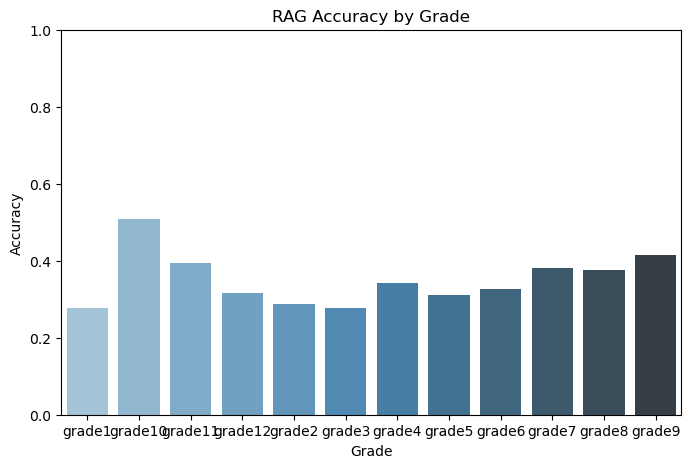

In [88]:
plt.figure(figsize=(8,5))
sns.barplot(x=acc_by_grade.index, y=acc_by_grade.values, palette="Blues_d")
plt.title("RAG Accuracy by Grade")
plt.xlabel("Grade")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## 8. Visualize Accuracy by Subject
Create a bar plot showing accuracy for each subject using matplotlib or seaborn.

/var/folders/7n/sdnmyc4j33q0y4lz8rx2m3wc0000gn/T/ipykernel_50391/2660238308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acc_by_subject.index, y=acc_by_subject.values, palette="Greens_d")


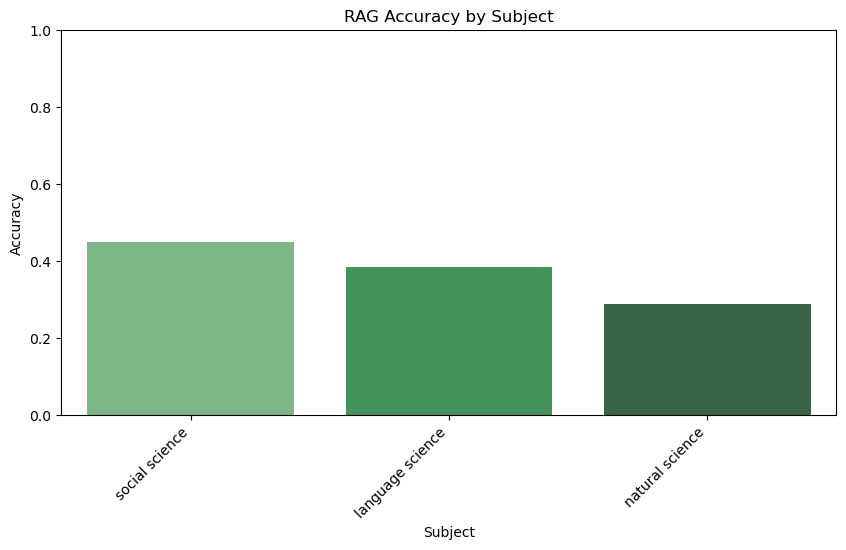

In [89]:
plt.figure(figsize=(10,5))
sns.barplot(x=acc_by_subject.index, y=acc_by_subject.values, palette="Greens_d")
plt.title("RAG Accuracy by Subject")
plt.xlabel("Subject")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.show()

## 6a. Calculate Accuracy for Grades 1-6 and 7-12
Group grades into 1-6 and 7-12, then calculate and display accuracy for each group.

In [90]:
# Convert grade to numeric (extract digits)
results_df['grade_num'] = results_df['grade'].str.extract(r'(\d+)').astype(float)

# Group grades
group_1_6 = results_df[results_df['grade_num'].between(1, 6)]
group_7_12 = results_df[results_df['grade_num'].between(7, 12)]

acc_1_6 = group_1_6['is_correct'].mean() if not group_1_6.empty else None
acc_7_12 = group_7_12['is_correct'].mean() if not group_7_12.empty else None

print(f"Accuracy for Grades 1-6: {acc_1_6:.2%}" if acc_1_6 is not None else "No data for Grades 1-6")
print(f"Accuracy for Grades 7-12: {acc_7_12:.2%}" if acc_7_12 is not None else "No data for Grades 7-12")

Accuracy for Grades 1-6: 30.94%
Accuracy for Grades 7-12: 39.56%


## 7a. Visualize Accuracy for Grades 1-6 and 7-12
Bar plot comparing accuracy for the two grade groups.

/var/folders/7n/sdnmyc4j33q0y4lz8rx2m3wc0000gn/T/ipykernel_50391/3165091099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=groups, y=accs, palette="Purples")


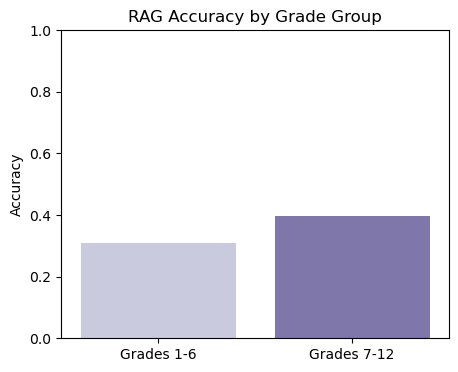

In [91]:
plt.figure(figsize=(5,4))
groups = ['Grades 1-6', 'Grades 7-12']
accs = [acc_1_6 if acc_1_6 is not None else 0, acc_7_12 if acc_7_12 is not None else 0]
sns.barplot(x=groups, y=accs, palette="Purples")
plt.title("RAG Accuracy by Grade Group")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()